In [60]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor
import shap
from interpret.glassbox import ExplainableBoostingRegressor
import optuna

warnings.filterwarnings('ignore')
matplotlib.rcParams['axes.unicode_minus'] = False
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [61]:
quarterly_df = pd.read_csv('../data/quarterly_model.csv')

In [62]:
ID_COLS = ['stock_code', 'year', 'quarter', 'induty_code']

SCORE_BUILDING_COLS = [
    'delisted',           # shifted → delisted_t1 → 계단식 패널티 계산 시작점
    'admin_designated',   # shifted → admin_t1    → 계단식 패널티 계산 시작점
    'audit_state_final',  # audit_penalty_final의 원본
    'audit_penalty_final', # 감사의견 패널티 직접 사용
]

FUTURE_LEAKAGE_COLS = [
    'delisted_t1',
    'admin_designated_t1',
    'audit_penalty_final_t1',
    'delisted_penalty_t1_step',  # target 구성 요소
    'admin_penalty_t1_step', 
    'admin_t1', 
    'audit_penalty_t1',
    'delisted_penalty_t1',
    'admin_penalty_t1'
]

DERIVED_SCORE_COLS = ['risk_score', 'delisted_penalty_step', 'admin_penalty_step']
TARGET_COL = 'target_score_t1'
EXCLUDE_ALL = set(ID_COLS + SCORE_BUILDING_COLS + FUTURE_LEAKAGE_COLS+ DERIVED_SCORE_COLS + [TARGET_COL])

# 수치형 피처만 선택
all_numeric   = quarterly_df.select_dtypes(include='number').columns.tolist()
feature_cols  = [c for c in all_numeric if c not in EXCLUDE_ALL]

actually_excluded = [c for c in EXCLUDE_ALL if c in quarterly_df.columns]

print(f'\n[피처 목록]')
for i, c in enumerate(feature_cols):
    print(f'  {i+1:2d}. {c}')


[피처 목록]
   1. capital
   2. capital_ratio
   3. asset_growth
   4. non_current_debt_ratio
   5. non_current_assets_ratio
   6. current_ratio
   7. non_current_assets
   8. non_current_liabilities
   9. current_debt_ratio
  10. short_term_debt_ratio
  11. current_assets_ratio
  12. net_working_capital_ratio
  13. current_liabilities
  14. current_assets
  15. debt_ratio
  16. debt_to_assets
  17. equity_ratio
  18. equity_multiplier
  19. total_assets
  20. equity
  21. total_liabilities


In [63]:
## 데이터 분할 및 평가 준비
X_all     = quarterly_df[feature_cols].copy()
valid_idx = X_all.notna().all(axis=1) & quarterly_df[TARGET_COL].notna()

clean_df  = quarterly_df.loc[valid_idx].copy()
X_all     = X_all.loc[valid_idx].copy()
y_all     = clean_df[TARGET_COL].copy()

train_mask = clean_df['year'] <= 2021
valid_mask = (clean_df['year'] >= 2022) & (clean_df['year'] <= 2023)
test_mask  = clean_df['year'] == 2024

X_train, y_train = X_all.loc[train_mask], y_all.loc[train_mask]
X_valid, y_valid = X_all.loc[valid_mask], y_all.loc[valid_mask]
X_test,  y_test  = X_all.loc[test_mask],  y_all.loc[test_mask]

# 기본 샘플 가중치: 낮은 점수(고위험)에 높은 가중치
sample_weight_base = np.clip(100 - y_train, 1, None)

print(f'Train (≤2021):   {X_train.shape}  | 고위험(≤70): {(y_train<=70).sum():3d}건 ({(y_train<=70).mean()*100:.1f}%)')
print(f'Valid (2022-23): {X_valid.shape}  | 고위험(≤70): {(y_valid<=70).sum():3d}건 ({(y_valid<=70).mean()*100:.1f}%)')
print(f'Test  (2024):    {X_test.shape}   | 고위험(≤70): {(y_test<=70).sum():3d}건  ({(y_test<=70).mean()*100:.1f}%)')

Train (≤2021):   (38424, 21)  | 고위험(≤70): 253건 (0.7%)
Valid (2022-23): (17031, 21)  | 고위험(≤70): 133건 (0.8%)
Test  (2024):    (9073, 21)   | 고위험(≤70): 218건  (2.4%)


In [64]:
# ── 공통 평가 함수 ────────────────────────────────────────────────────
def eval_model(name, y_true, y_pred, split='valid'):
    """MAE / RMSE / 고위험 구간 MAE / ±10점 정확도 반환"""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # 고위험 기업 기준 파악
    low  = y_true <= 70
    low_mae  = mean_absolute_error(y_true[low], y_pred[low]) if low.sum() > 0 else np.nan
    
    # 고위험 기업(70점 이하)에 대해 예측이 실제 점수로부터 +=10 점이내에 들어온 비율 확인
    within10 = (np.abs(y_pred[low] - y_true[low]) <= 10).mean() * 100 if low.sum() > 0 else np.nan
    
    return {
        'model': name, 'split': split,
        'MAE':              round(mae, 3),
        'RMSE':             round(rmse, 3),
        'LOW_MAE(≤70)':     round(low_mae, 3)   if not np.isnan(low_mae)   else np.nan,
        'RISK_ACC(±10)%':   round(within10, 1)  if not np.isnan(within10)  else np.nan,
    }
    
all_results = []   # 전체 결과 누적
fitted_models = {} # 학습된 모델 저장

### EBM — Optuna 하이퍼파라미터 튜닝

**목적함수**: `MAE + 0.3 × LOW_MAE(≤70)` — 전체 정확도를 최소화하되 고위험 예측 오류에 추가 패널티

| 탐색 파라미터 | 범위 | 의미 |
|---|---|---|
| `max_bins` | 64–512 (step 64) | 연속형 변수 이산화 구간 수 |
| `interactions` | 0–20 | 학습할 pairwise interaction 항 수 |
| `learning_rate` | 0.005–0.1 (log) | 각 round의 학습 보폭 |
| `max_leaves` | 2–5 | 트리 깊이 제어 |
| `min_samples_leaf` | 1–15 | 리프 최소 샘플 수 |


 Optuna 탐색 시작 (10 trials)...

  ✓ Best objective : 4.7298
  ✓ Best params    : {'max_bins': 192, 'interactions': 19, 'learning_rate': 0.044803926826840625, 'max_leaves': 4, 'min_samples_leaf': 3}

  [최적 파라미터로 최종 EBM 학습 중...]

  [성능 평가]
  [valid] MAE=4.730  LOW_MAE=21.660  RISK_ACC=15.0%
  [test ] MAE=5.740  LOW_MAE=21.302  RISK_ACC=22.5%

  [EBM Global Feature Importance]
                                 feature  importance
                           capital_ratio    2.682178
                                 capital    1.737050
               net_working_capital_ratio    1.655261
                            asset_growth    1.497624
                  non_current_debt_ratio    1.424954
                                  equity    1.422919
                          debt_to_assets    1.383351
                      non_current_assets    1.260297
                          current_assets    1.230120
                 non_current_liabilities    1.221265
                      current_debt_ratio  

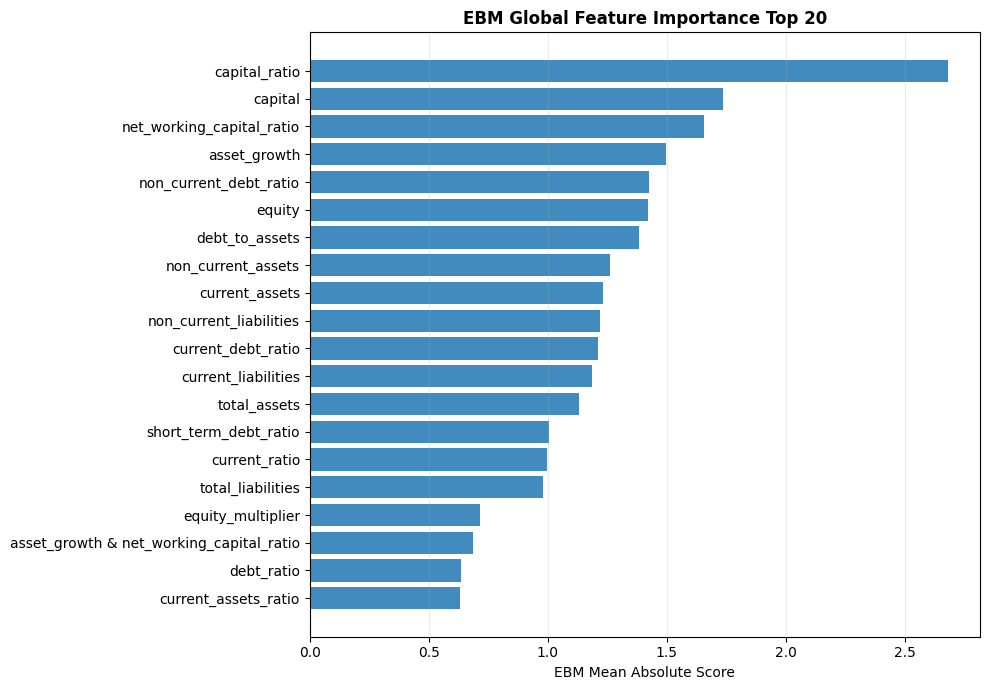

In [65]:
def _ebm_objective(trial):
    params = {
        'max_bins':         trial.suggest_int('max_bins', 64, 512, step=64),
        'interactions':     trial.suggest_int('interactions', 0, 20),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_leaves':       trial.suggest_int('max_leaves', 2, 5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'random_state': 42,
    }
    m = ExplainableBoostingRegressor(**params)
    m.fit(X_train, y_train, sample_weight=sample_weight_base)
    pred = np.clip(m.predict(X_valid), 0, 100)
    mae = mean_absolute_error(y_valid, pred)
    return mae 


study_ebm = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
print(' Optuna 탐색 시작 (10 trials)...')
study_ebm.optimize(_ebm_objective, n_trials=10, show_progress_bar=False)

print(f'\n  ✓ Best objective : {study_ebm.best_value:.4f}')
print(f'  ✓ Best params    : {study_ebm.best_params}')

# ── 최적 파라미터로 최종 EBM 학습 ───────────────────────────────
best_ebm_params = {**study_ebm.best_params, 'random_state': 42}
print('\n  [최적 파라미터로 최종 EBM 학습 중...]')
ebm = ExplainableBoostingRegressor(**best_ebm_params)
ebm.fit(X_train, y_train, sample_weight=sample_weight_base)
fitted_models['D2_1_EBM'] = ebm

print('\n  [성능 평가]')
for split, X, y in [('valid', X_valid, y_valid), ('test', X_test, y_test)]:
    pred = np.clip(ebm.predict(X), 0, 100)
    r = eval_model('D2_1_EBM', y, pred, split)
    all_results.append(r)
    print(f'  [{split:5s}] MAE={r["MAE"]:.3f}  LOW_MAE={r["LOW_MAE(≤70)"]:.3f}  RISK_ACC={r["RISK_ACC(±10)%"]:.1f}%')

# ── Global Feature Importance ───────────────────────────
print('\n  [EBM Global Feature Importance]')
try:
    global_exp = ebm.explain_global()
    g = global_exp.data()
    imp = pd.DataFrame({
        'feature':    g['names'],
        'importance': g['scores'],
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    # 상호작용 제외한 단변수 항만 표시
    imp_univ = imp[~imp['feature'].astype(str).str.contains(' x ')].head(20)
    print(imp_univ.to_string(index=False))
    
    top_n = min(20, len(imp_univ))
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(range(top_n), imp_univ['importance'].values[:top_n][::-1],
            color='#1f77b4', alpha=0.85)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(imp_univ['feature'].values[:top_n][::-1], fontsize=10)
    ax.set_xlabel('EBM Mean Absolute Score')
    ax.set_title('EBM Global Feature Importance Top 20', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout(); plt.show()
except Exception as e:
    print('  Global explanation 생성 실패:', e)

### EBM 추가 결과 해석

Feature Importance 막대 차트 이외의 EBM 전용 해석 도구:
| 섹션 | 내용 |
|------|------|
| Shape Functions | 각 피처값이 Risk Score에 미치는 비선형 기여 곡선|
| Interaction Heatmap | 상위 pairwise 상호작용 효과 2D 시각화 |
| Score Distribution | 전체·고위험 구간 예측 vs 실제 점수 분포 비교 |
| Waterfall Charts | 고위험 기업 3개 — 피처별 기여 분해 워터폴 차트 |

EBM Shape Functions — 피처별 비선형 기여 곡선
양수 기여 → Risk Score ↑ (건강) | 음수 기여 → Risk Score ↓ (위험)


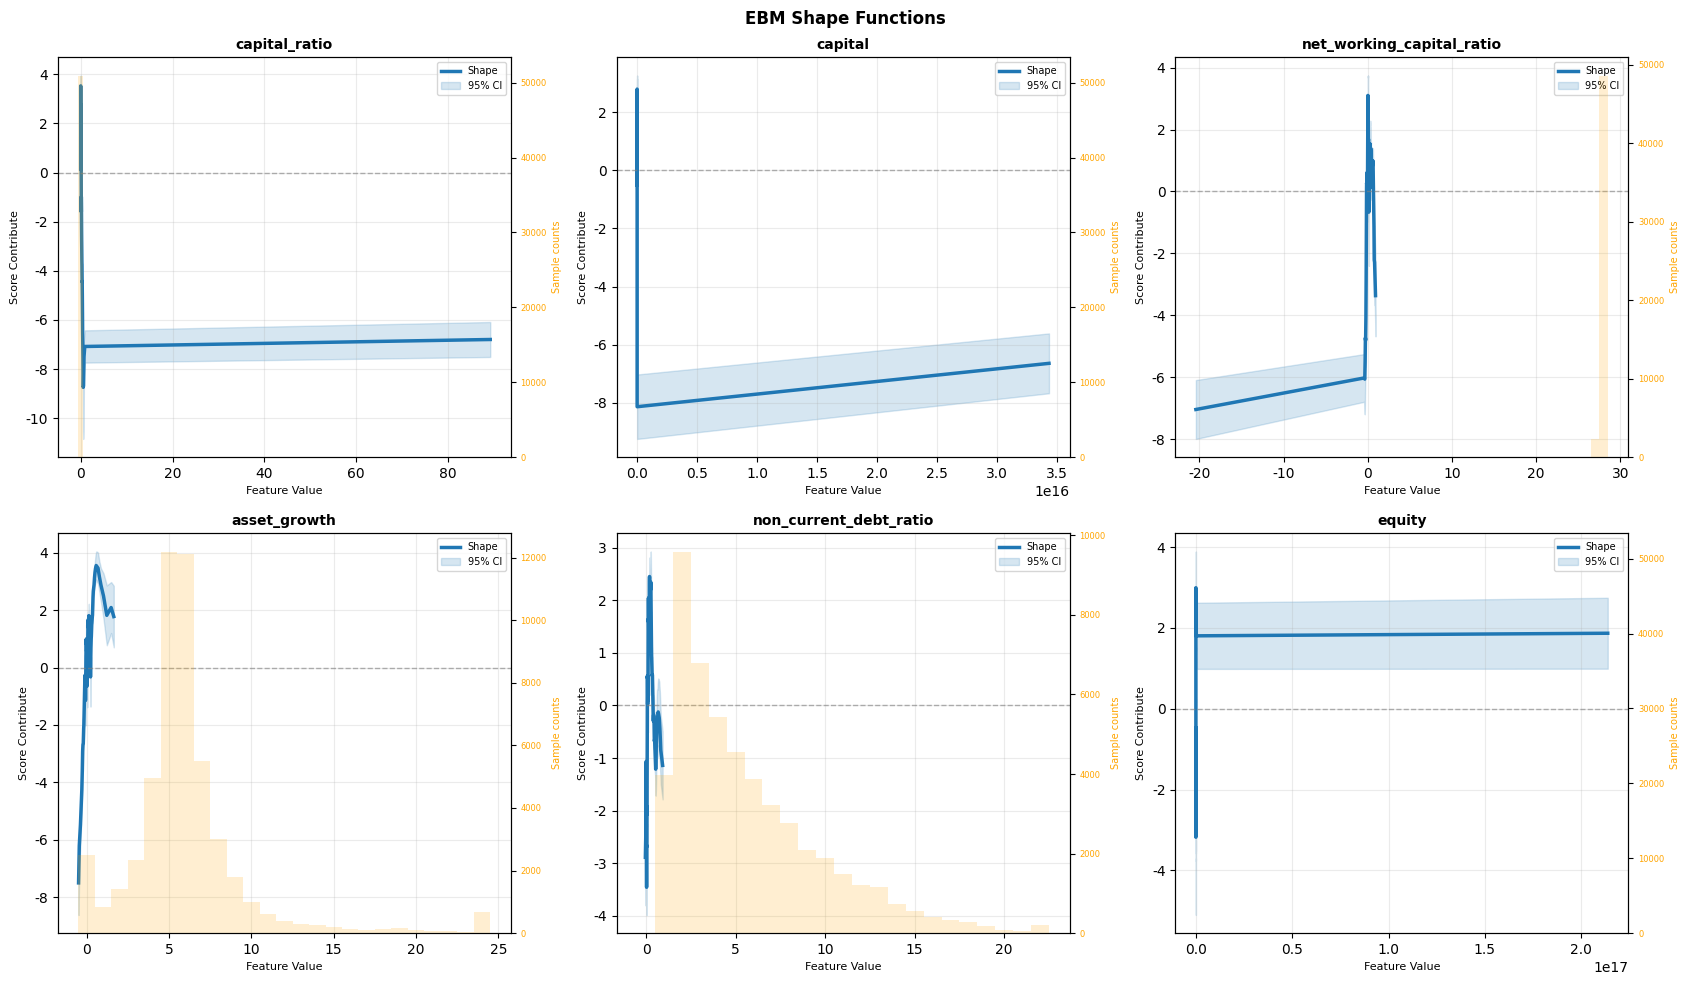

In [66]:
# ── [1] EBM Shape Functions — 피처별 비선형 기여 곡선 ────────────────────
print('EBM Shape Functions — 피처별 비선형 기여 곡선')
print('양수 기여 → Risk Score ↑ (건강) | 음수 기여 → Risk Score ↓ (위험)')

names_all  = g.get('names', [])   
scores_all = g.get('scores', [])  

univ_pairs = [(n, s, i) for i, (n, s) in enumerate(zip(names_all, scores_all)) if ' x ' not in str(n)]
univ_pairs_sorted = sorted(univ_pairs, key=lambda x: -x[1])
top6 = univ_pairs_sorted[:6]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes = axes.flatten()

for plot_i, (feat_name, _, feat_idx) in enumerate(top6):
    ax = axes[plot_i]
    try:
        fd = global_exp.data(feat_idx)
    except Exception:
        ax.axis('off'); continue

    if fd.get('type') != 'univariate':
        ax.axis('off'); continue

    x_names = fd.get('names', [])
    y_vals  = np.array(fd.get('scores', []))
    y_up    = np.array(fd.get('upper_bounds', y_vals))
    y_lo    = np.array(fd.get('lower_bounds', y_vals))

    if len(x_names) == len(y_vals) + 1:
        try:
            x_plot = [(float(x_names[i]) + float(x_names[i+1])) / 2
            for i in range(len(x_names) - 1)]
        except (TypeError, ValueError):
            x_plot = list(range(len(y_vals)))
    else:
        x_plot = list(range(len(y_vals)))

    ax.plot(x_plot, y_vals, color='#1f77b4', lw=2.5, label='Shape')
    if len(y_up) == len(y_vals) and len(y_lo) == len(y_vals):
        ax.fill_between(x_plot, y_lo, y_up, alpha=0.18, color='#1f77b4', label='95% CI')
    ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.6)

    density = fd.get('density', {})
    if density and 'scores' in density:
        ax2 = ax.twinx()
        ax2.bar(range(len(density['scores'])), density['scores'],
                alpha=0.18, color='orange', width=1)
        ax2.set_ylabel('Sample counts', fontsize=7, color='orange')
        ax2.tick_params(axis='y', labelsize=6, labelcolor='orange')

    ax.set_title(feat_name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Feature Value', fontsize=8)
    ax.set_ylabel('Score Contribute', fontsize=8)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7)

plt.suptitle('EBM Shape Functions', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

예측 점수 분포 비교 (실제 vs EBM 예측)
→ 모델이 저점수(고위험) 구간을 얼마나 잘 포착하는지


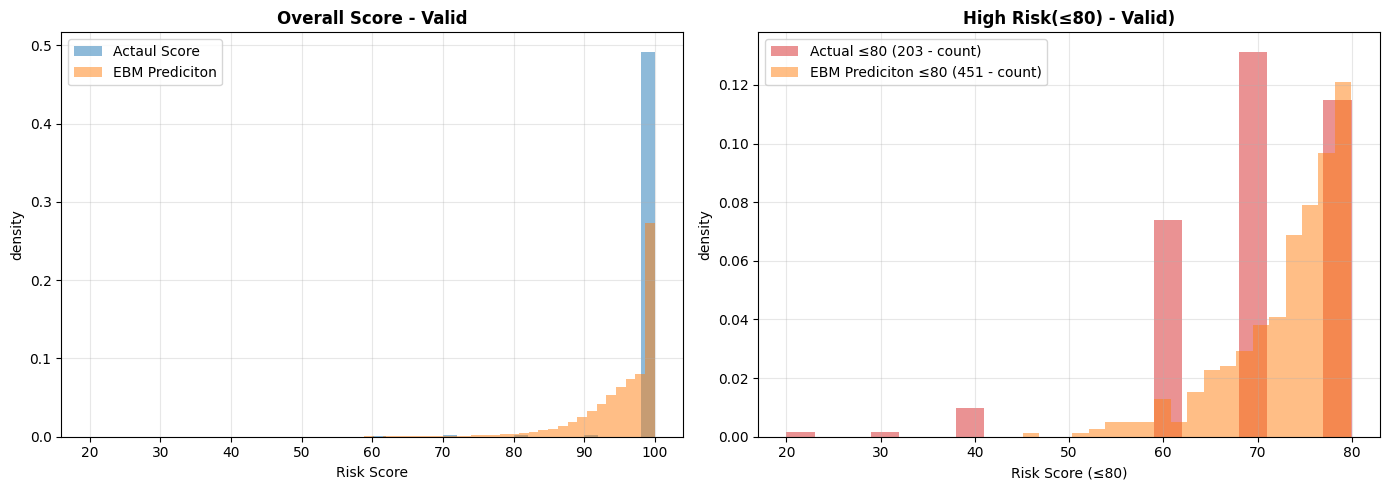

실제 ≤60:   53건 | EBM 예측 ≤60:   22건(비율: 42%)
실제 ≤70:  133건 | EBM 예측 ≤70:  106건(비율: 80%)
실제 ≤80:  203건 | EBM 예측 ≤80:  451건(비율: 222%)
실제 ≤90:  277건 | EBM 예측 ≤90: 2389건(비율: 862%)


In [67]:
# ── 예측 점수 분포 비교 ───────────────────────────────────────────────
print('=' * 65)
print('예측 점수 분포 비교 (실제 vs EBM 예측)')
print('→ 모델이 저점수(고위험) 구간을 얼마나 잘 포착하는지')
print('=' * 65)

pred_v = np.clip(ebm.predict(X_valid), 0, 100)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(y_valid, bins=40, alpha=0.5, color='#1f77b4', label='Actaul Score', density=True)
ax.hist(pred_v,  bins=40, alpha=0.5, color='#ff7f0e', label='EBM Prediciton',  density=True)
ax.set_xlabel('Risk Score'); ax.set_ylabel('density')
ax.set_title('Overall Score - Valid', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
mask_a80 = y_valid <= 80
mask_p80 = pred_v  <= 80
ax.hist(y_valid[mask_a80], bins=20, alpha=0.5, color='#d62728',
        label=f'Actual ≤80 ({mask_a80.sum()} - count)', density=True)
ax.hist(pred_v[mask_p80],  bins=20, alpha=0.5, color='#ff7f0e',
        label=f'EBM Prediciton ≤80 ({mask_p80.sum()} - count)', density=True)
ax.set_xlabel('Risk Score (≤80)'); ax.set_ylabel('density')
ax.set_title('High Risk(≤80) - Valid)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

for thr in [60, 70, 80, 90]:
    a_cnt = (y_valid <= thr).sum()
    p_cnt = (pred_v  <= thr).sum()
    print(f'실제 ≤{thr}: {a_cnt:4d}건 | EBM 예측 ≤{thr}: {p_cnt:4d}건'
          f'(비율: {p_cnt/max(a_cnt,1)*100:.0f}%)')

---
# DEVELOPMENT 모델
---
> Baseline 대비 개선을 목표로 다양한 전략을 실험합니다.
>
> | 전략 | 내용 |
> |------|------|
> | D1. Tree Ensemble | RF / ExtraTrees / XGBoost / LightGBM |
> | D2. 가중치 전략 | 고위험 샘플 가중치 방식 비교 |
> | D2-1. EBM | Explainable Boosting Machine (해석 가능한 비선형) |
> | D3. Stacking | ET + LightGBM → ElasticNet 메타 학습 |
> | D4. Two-stage | 분류(고위험 여부) → 회귀(정확한 점수) |


### D1. Tree Ensemble 모델

In [68]:
print('=' * 55)
print('D1. Tree Ensemble 모델 (기본 가중치 적용)')
print('=' * 55)

dev_models = {
    'D1_ExtraTrees': ExtraTreesRegressor(
        n_estimators=600, min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    'D1_RandomForest': RandomForestRegressor(
        n_estimators=600, min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    'D1_XGBoost': XGBRegressor(
        n_estimators=800, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    ),
    'D1_LightGBM': LGBMRegressor(
        n_estimators=800, learning_rate=0.03, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    ),
}
for name, model in dev_models.items():
    model.fit(X_train, y_train, sample_weight=sample_weight_base)
    fitted_models[name] = model

    for split, X, y in [('valid', X_valid, y_valid), ('test', X_test, y_test)]:
        pred = np.clip(model.predict(X), 0, 100)
        r = eval_model(name, y, pred, split)
        all_results.append(r)

    rv = eval_model(name, y_valid, np.clip(model.predict(X_valid), 0, 100), 'valid')
    print(f'  [{name:20s}] MAE={rv["MAE"]:.3f} RMSE={rv["RMSE"]:.3f} LOW_MAE={rv["LOW_MAE(≤70)"]:.3f} RISK_ACC={rv["RISK_ACC(±10)%"]:.1f}%')

D1. Tree Ensemble 모델 (기본 가중치 적용)
  [D1_ExtraTrees       ] MAE=0.997 RMSE=3.656 LOW_MAE=30.408 RISK_ACC=2.3%
  [D1_RandomForest     ] MAE=0.956 RMSE=3.562 LOW_MAE=30.873 RISK_ACC=1.5%


  [D1_XGBoost          ] MAE=1.542 RMSE=4.066 LOW_MAE=30.167 RISK_ACC=3.0%
  [D1_LightGBM         ] MAE=1.598 RMSE=4.320 LOW_MAE=28.182 RISK_ACC=6.0%


In [69]:
print('=' * 65)
print('D1-Tuned. ExtraTrees — Optuna 하이퍼파라미터 튜닝 예시')
print('  목적함수: MAE + 0.3 × LOW_MAE(≤70)')
print('=' * 65)

def _et_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 800, step=100),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 8),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
        'max_depth':         trial.suggest_categorical('max_depth', [None, 10, 15, 20, 30]),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5, 0.7]),
        'random_state': 42,
        'n_jobs': -1,
    }
    m = ExtraTreesRegressor(**params)
    m.fit(X_train, y_train, sample_weight=sample_weight_base)
    pred = np.clip(m.predict(X_valid), 0, 100)
    mae = mean_absolute_error(y_valid, pred)
    return mae 

study_et = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
print('  Optuna 탐색 시작 (10 trials)...')
study_et.optimize(_et_objective, n_trials=10, show_progress_bar=True)

print(f'\n  ✓ Best objective : {study_et.best_value:.4f}')
print(f'  ✓ Best params    : {study_et.best_params}')

# ── 최적 파라미터로 최종 ExtraTrees 학습 ─────────────────────────────
best_et_params = {**study_et.best_params, 'random_state': 42, 'n_jobs': -1}
print('\n  [최적 파라미터로 최종 ExtraTrees 학습 중...]')
et_tuned = ExtraTreesRegressor(**best_et_params)
et_tuned.fit(X_train, y_train, sample_weight=sample_weight_base)
fitted_models['D1_ExtraTrees_Tuned'] = et_tuned

print('\n  [성능 비교: 기본 vs Tuned]')
for split, X, y in [('valid', X_valid, y_valid), ('test', X_test, y_test)]:
    pred_base  = np.clip(fitted_models['D1_ExtraTrees'].predict(X), 0, 100)
    pred_tuned = np.clip(et_tuned.predict(X), 0, 100)
    rb = eval_model('D1_ExtraTrees',       y, pred_base,  split)
    rt = eval_model('D1_ExtraTrees_Tuned', y, pred_tuned, split)
    all_results.append(rt)
    print(f'  [{split:5s}] Base  MAE={rb["MAE"]:.3f}  LOW_MAE={rb["LOW_MAE(≤70)"]:.3f}  RISK_ACC={rb["RISK_ACC(±10)%"]:.1f}%')
    print(f'  [{split:5s}] Tuned MAE={rt["MAE"]:.3f}  LOW_MAE={rt["LOW_MAE(≤70)"]:.3f}  RISK_ACC={rt["RISK_ACC(±10)%"]:.1f}%')
    print()

D1-Tuned. ExtraTrees — Optuna 하이퍼파라미터 튜닝 예시
  목적함수: MAE + 0.3 × LOW_MAE(≤70)
  Optuna 탐색 시작 (10 trials)...


Best trial: 3. Best value: 1.3662: 100%|██████████| 10/10 [00:07<00:00,  1.27it/s]



  ✓ Best objective : 1.3662
  ✓ Best params    : {'n_estimators': 400, 'min_samples_leaf': 1, 'min_samples_split': 6, 'max_depth': 30, 'max_features': 'log2'}

  [최적 파라미터로 최종 ExtraTrees 학습 중...]

  [성능 비교: 기본 vs Tuned]
  [valid] Base  MAE=0.997  LOW_MAE=30.408  RISK_ACC=2.3%
  [valid] Tuned MAE=1.366  LOW_MAE=29.666  RISK_ACC=3.0%

  [test ] Base  MAE=1.682  LOW_MAE=29.432  RISK_ACC=0.9%
  [test ] Tuned MAE=2.026  LOW_MAE=28.855  RISK_ACC=2.8%



### D2. 샘플 가중치 전략 실험

고위험 기업(낮은 점수)에 더 집중하기 위해 다양한 가중치 방식을 비교합니다.

| 전략 | 수식 | 특징 |
|------|------|------|
| linear | clip(100 - y, 1) | 현재 방식, 선형 |
| quadratic | clip((100-y)²/100, 1) | 극단 고위험에 집중 |
| log | log(1 + clip(100-y)) | 완만한 가중치 |
| binary | y≤70 → 30, else → 1 | 고위험에 30배 |
| no_weight | — | 가중치 없음 |

In [70]:
print('=' * 55)
print('D2. 샘플 가중치 전략 실험')
print('=' * 55)

weight_strategies = {
    'D2_ET_linear':    np.clip(100 - y_train, 1, None),
    'D2_ET_quadratic': np.clip((100 - y_train)**2 / 100, 1, None),
    'D2_ET_log':       np.log1p(np.clip(100 - y_train, 0, None)) + 1,
    'D2_ET_binary':    np.where(y_train <= 70, 30, 1),
    'D2_ET_no_weight': None,
}

best_w_name, best_w_mae = None, np.inf

for name, w in weight_strategies.items():
    # RandomForestRegressor 기준
    m = RandomForestRegressor(n_estimators=600, min_samples_leaf=2, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train, sample_weight=w) if w is not None else m.fit(X_train, y_train)
    fitted_models[name] = m

    for split, X, y in [('valid', X_valid, y_valid), ('test', X_test, y_test)]:
        pred = np.clip(m.predict(X), 0, 100)
        r = eval_model(name, y, pred, split)
        all_results.append(r)

    rv = eval_model(name, y_valid, np.clip(m.predict(X_valid), 0, 100), 'valid')
    marker = ' ◀ best' if rv['MAE'] < best_w_mae else ''
    if rv['MAE'] < best_w_mae:
        best_w_mae, best_w_name = rv['MAE'], name
    print(f'  [{name:22s}] MAE={rv["MAE"]:.3f}  LOW_MAE={rv["LOW_MAE(≤70)"]:.3f}  RISK_ACC={rv["RISK_ACC(±10)%"]:.1f}%{marker}')

print(f'\n  → 최적 가중치 전략: {best_w_name} (Valid MAE={best_w_mae:.3f})')

D2. 샘플 가중치 전략 실험


  [D2_ET_linear          ] MAE=0.956  LOW_MAE=30.873  RISK_ACC=1.5% ◀ best
  [D2_ET_quadratic       ] MAE=0.983  LOW_MAE=31.101  RISK_ACC=1.5%
  [D2_ET_log             ] MAE=0.951  LOW_MAE=31.011  RISK_ACC=2.3% ◀ best
  [D2_ET_binary          ] MAE=0.911  LOW_MAE=31.205  RISK_ACC=1.5% ◀ best
  [D2_ET_no_weight       ] MAE=0.852  LOW_MAE=31.366  RISK_ACC=1.5% ◀ best

  → 최적 가중치 전략: D2_ET_no_weight (Valid MAE=0.852)


### D3. Stacking 앙상블

- **Level 1**: ExtraTrees + LightGBM (5-fold OOF 예측 생성)
- **Level 2**: ElasticNet 메타 학습 (OOF 예측을 피처로 사용)

> OOF(Out-of-Fold) 방식을 사용하여 메타 학습 시 data leakage 방지

In [71]:
print('=' * 55)
print('D3. Stacking 앙상블 (OOF 기반)')
print('=' * 55)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def oof_predict(model, X, y, w=None):
    """5-fold OOF 예측 생성 (메타 학습용)"""
    oof = np.zeros(len(y))
    for tr_idx, va_idx in kf.split(X):
        Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
        ytr = y.iloc[tr_idx]
        wtr = w.iloc[tr_idx] if w is not None else None
        clone = type(model)(**model.get_params())
        clone.fit(Xtr, ytr, sample_weight=wtr) if wtr is not None else clone.fit(Xtr, ytr)
        oof[va_idx] = clone.predict(Xva)
    return oof

sw = pd.Series(sample_weight_base.values, index=y_train.index)

et_oof  = oof_predict(fitted_models['D1_ExtraTrees'], X_train, y_train, sw)
lgb_oof = oof_predict(fitted_models['D1_LightGBM'],   X_train, y_train, sw)

# Level-1 예측 (valid/test)
et_v  = np.clip(fitted_models['D1_ExtraTrees'].predict(X_valid), 0, 100)
et_t  = np.clip(fitted_models['D1_ExtraTrees'].predict(X_test),  0, 100)
lgb_v = np.clip(fitted_models['D1_LightGBM'].predict(X_valid),   0, 100)
lgb_t = np.clip(fitted_models['D1_LightGBM'].predict(X_test),    0, 100)

# Level-2 메타학습
meta_X_train = np.column_stack([et_oof, lgb_oof])
meta_X_valid = np.column_stack([et_v,   lgb_v])
meta_X_test  = np.column_stack([et_t,   lgb_t])

meta_lr = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
meta_lr.fit(meta_X_train, y_train)
fitted_models['D3_Stacking(ET+LGB→ENet)'] = meta_lr

for split, mX, y in [('valid', meta_X_valid, y_valid), ('test', meta_X_test, y_test)]:
    pred = np.clip(meta_lr.predict(mX), 0, 100)
    r = eval_model('D3_Stacking(ET+LGB→ENet)', y, pred, split)
    all_results.append(r)
    print(f'  [{split:5s}] MAE={r["MAE"]:.3f}  LOW_MAE={r["LOW_MAE(≤70)"]:.3f}  RISK_ACC={r["RISK_ACC(±10)%"]:.1f}%')

print(f'\n  메타 가중치: ET={meta_lr.coef_[0]:.3f} / LGB={meta_lr.coef_[1]:.3f}')

D3. Stacking 앙상블 (OOF 기반)
  [valid] MAE=0.785  LOW_MAE=31.759  RISK_ACC=1.5%
  [test ] MAE=1.466  LOW_MAE=30.800  RISK_ACC=0.0%

  메타 가중치: ET=0.624 / LGB=0.088


## 5. 전체 모델 성능 비교 리더보드

In [112]:
results_df = pd.DataFrame(all_results)

valid_lb = results_df[results_df['split'] == 'valid'].copy()
test_lb  = results_df[results_df['split'] == 'test'].copy()

valid_lb = valid_lb.drop_duplicates(subset='model', keep='last')
test_lb  = test_lb.drop_duplicates(subset='model', keep='last')

lb = valid_lb.merge(
    test_lb[['model', 'MAE', 'RMSE', 'LOW_MAE(≤70)', 'RISK_ACC(±10)%']],
    on='model', suffixes=('_v', '_t')
).sort_values('MAE_v').rename(columns={
    'MAE_v': 'V_MAE', 'RMSE_v': 'V_RMSE', 'LOW_MAE(≤70)_v': 'V_LOW_MAE', 'RISK_ACC(±10)%_v': 'V_RISK_ACC',
    'MAE_t': 'T_MAE', 'RMSE_t': 'T_RMSE', 'LOW_MAE(≤70)_t': 'T_LOW_MAE', 'RISK_ACC(±10)%_t': 'T_RISK_ACC',
})

display_cols = ['model', 'V_MAE', 'V_RMSE', 'V_LOW_MAE', 'V_RISK_ACC', 'T_MAE', 'T_RMSE', 'T_LOW_MAE', 'T_RISK_ACC']
final_lb = lb[[c for c in display_cols if c in lb.columns]].reset_index(drop=True)

print('━' * 80)
print('전체 모델 성능 비교 (Valid MAE 오름차순)')
print('━' * 80)
print(final_lb.to_string(index=False))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
전체 모델 성능 비교 (Valid MAE 오름차순)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
              model  V_MAE  V_RMSE  V_LOW_MAE  V_RISK_ACC  T_MAE  T_RMSE  T_LOW_MAE  T_RISK_ACC
    D2_ET_no_weight  0.852   3.541     31.366         1.5  2.035   5.698     30.300         0.5
       D2_ET_binary  0.911   3.544     31.205         1.5  2.033   5.633     30.107         0.0
          D2_ET_log  0.951   3.577     31.011         2.3  2.252   5.740     29.792         0.5
    D1_RandomForest  0.956   3.562     30.873         1.5  2.067   5.633     29.900         0.0
       D2_ET_linear  0.956   3.562     30.873         1.5  2.067   5.633     29.900         0.0
    D2_ET_quadratic  0.983   3.648     31.101         1.5  2.331   5.810     30.145         0.0
      D1_ExtraTrees  0.997   3.656     30.408         2.3  1.682   5.503     29.432         0.9
D1_ExtraTrees_Tuned  1.366   3.726     29

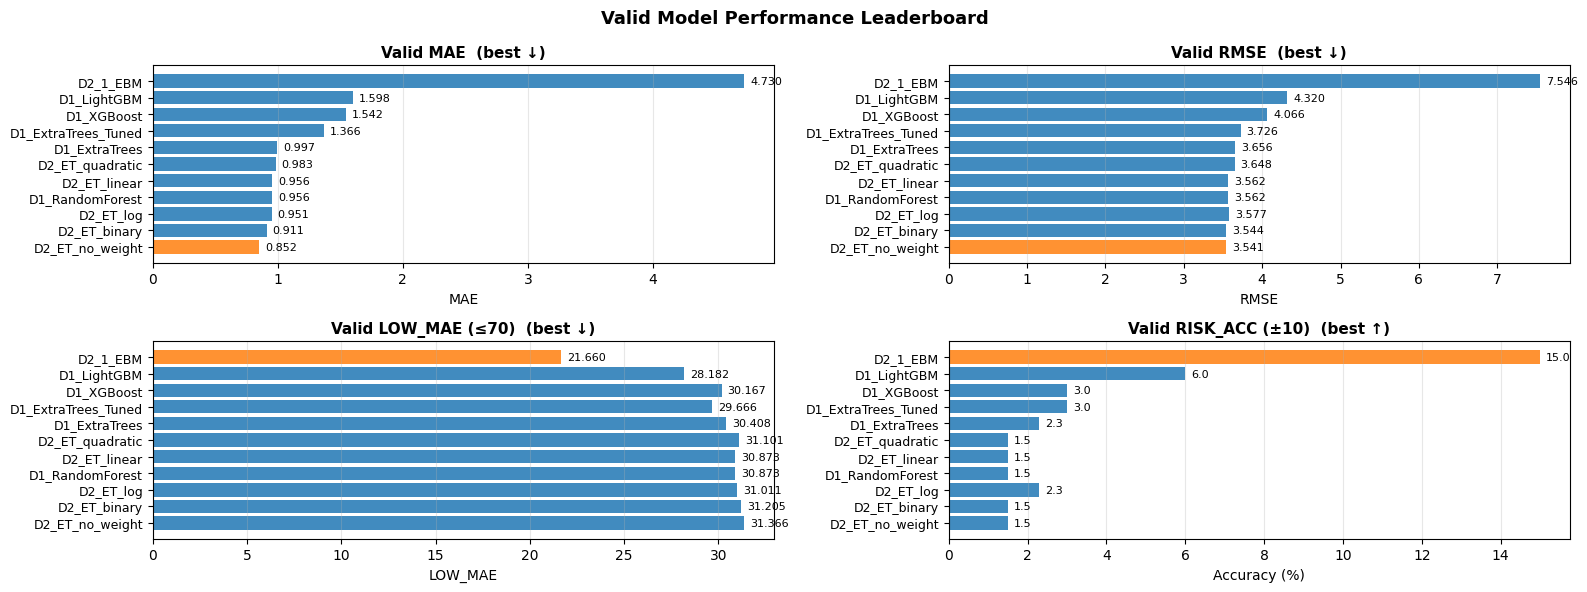

In [113]:
# ── 4-metric 리더보드 시각화 (2×2) ───────────────────────────────────
def plot_4_metrics_leaderboard(df, prefix="V_", title_prefix="Valid", sort_by=None):
    metrics = [
        (f"{prefix}MAE",      f"{title_prefix} MAE",            "lower"),
        (f"{prefix}RMSE",     f"{title_prefix} RMSE",           "lower"),
        (f"{prefix}LOW_MAE",  f"{title_prefix} LOW_MAE (≤70)",  "lower"),
        (f"{prefix}RISK_ACC", f"{title_prefix} RISK_ACC (±10)", "higher"),
    ]
    metrics = [(c, t, d) for (c, t, d) in metrics if c in df.columns]

    if sort_by is None:
        sort_by = f"{prefix}MAE" if f"{prefix}MAE" in df.columns else metrics[0][0]

    dff = df.sort_values(sort_by, ascending="RISK" not in sort_by).reset_index(drop=True)
    names = dff["model"].astype(str).values
    n = len(dff)

    n_cols = 2
    n_rows = (len(metrics) + 1) // n_cols
    fig_h = max(6, n * 0.45) * n_rows / 2  # 행 수 반영
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, fig_h))
    axes = axes.flatten()

    for ax_i, ax in enumerate(axes):
        if ax_i >= len(metrics):
            ax.axis("off")
            continue

        col, title, direction = metrics[ax_i]
        vals = dff[col].to_numpy(dtype=float)

        if direction == "lower":
            best, better = np.nanmin(vals), "↓"
        else:
            best, better = np.nanmax(vals), "↑"

        bar_colors = ["#ff7f0e" if (not np.isnan(v) and v == best) else "#1f77b4" for v in vals]

        ax.barh(range(n), vals, color=bar_colors, alpha=0.85)
        ax.set_title(f"{title}  (best {better})", fontsize=11, fontweight="bold")
        ax.grid(axis="x", alpha=0.3)

        # 모든 서브플롯에 y 레이블 표시
        ax.set_yticks(range(n))
        ax.set_yticklabels(names, fontsize=9)

        ax.set_xlabel("Accuracy (%)" if "RISK_ACC" in col else col.replace(prefix, ""))

        x_max = np.nanmax(vals) if np.isfinite(np.nanmax(vals)) else 0.0
        pad = x_max * 0.01 if x_max > 0 else 0.01
        for i, v in enumerate(vals):
            if not np.isnan(v):
                label = f"{v:.1f}" if "RISK" in col else f"{v:.3f}"
                ax.text(v + pad, i, label, va="center", fontsize=8)

    fig.suptitle(f"{title_prefix} Model Performance Leaderboard", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_4_metrics_leaderboard(final_lb, prefix="V_", title_prefix="Valid", sort_by="V_MAE")

## 6. 최적 모델 분석

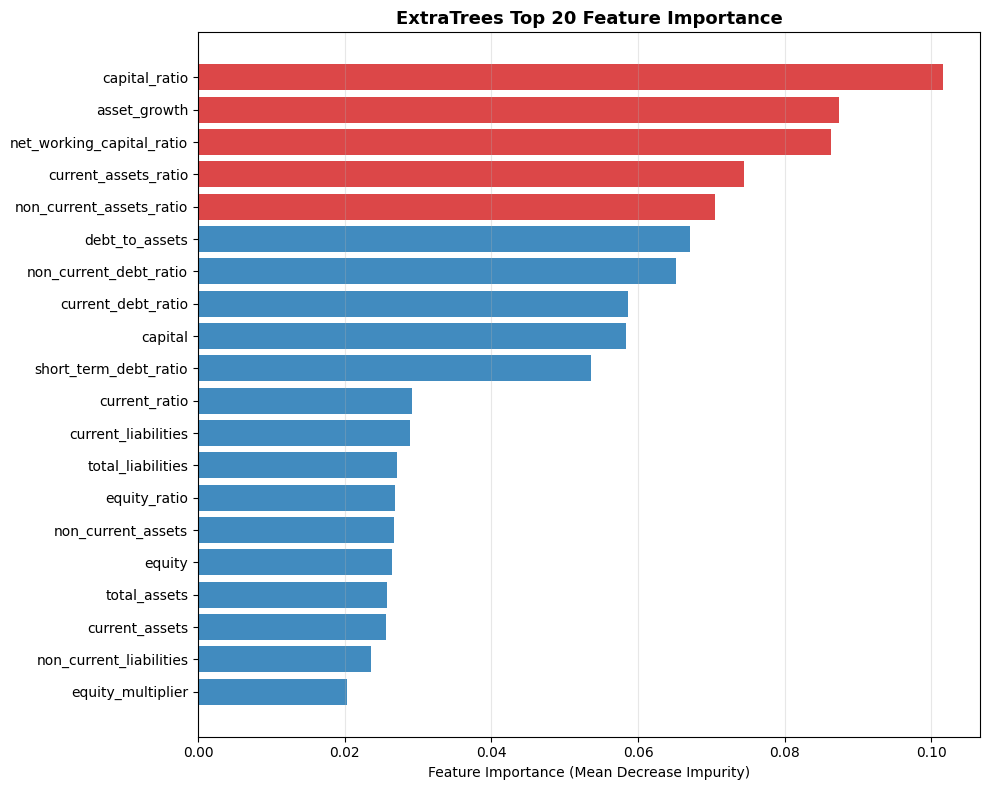

In [74]:
# ── 피처 중요도 (Stacking 전체: Permutation Importance) ──────────────────────────
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

stack_key = 'D3_Stacking(ET+LGB→ENet)'
best_model = fitted_models.get(stack_key)

def stacking_predict(X):
    et_pred = np.clip(fitted_models['D1_ExtraTrees'].predict(X), 0, 100)
    lgb_pred = np.clip(fitted_models['D1_LightGBM'].predict(X), 0, 100)
    meta_X = np.column_stack([et_pred, lgb_pred])
    return np.clip(best_model.predict(meta_X), 0, 100)

class _StackingWrapper(BaseEstimator, RegressorMixin):
    def fit(self, X, y):
        return self
    def predict(self, X):
        return stacking_predict(X)

wrapper = _StackingWrapper()

# Permutation Importance on validation set
perm = permutation_importance(
    estimator=wrapper,
    X=X_valid,
    y=y_valid,
    scoring='neg_mean_absolute_error',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

fi_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': -perm.importances_mean
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_n = min(20, len(fi_df))
top_fi = fi_df.head(top_n)

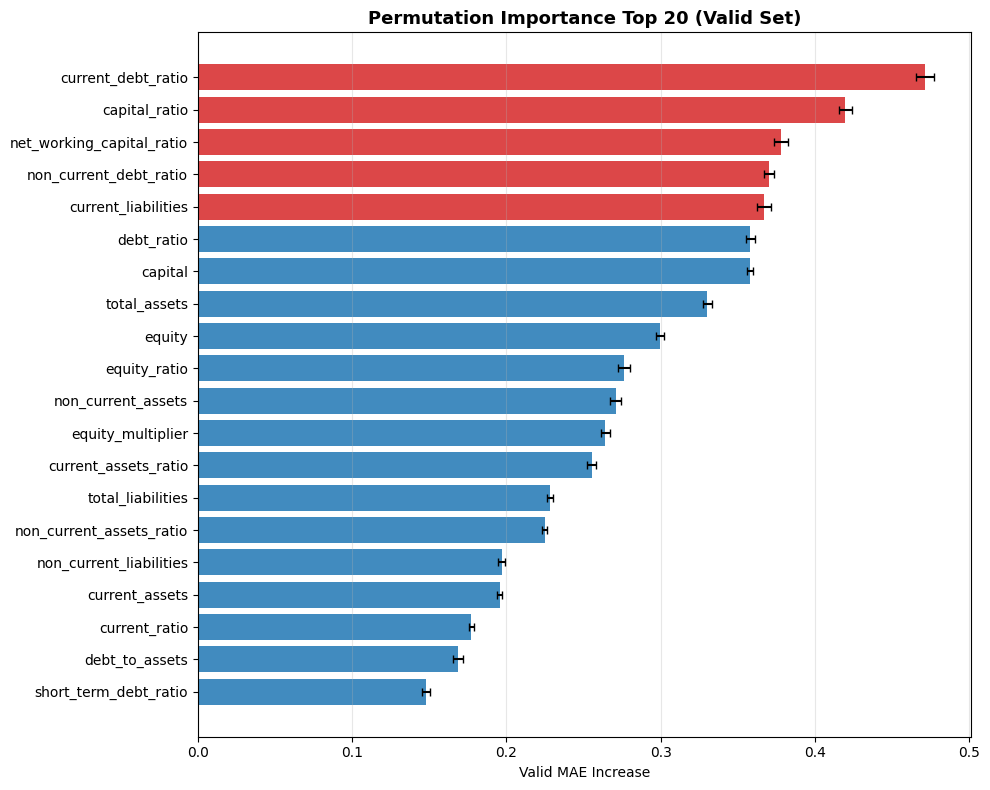


[Permutation Importance Top 20]
                  feature  perm_mae_increase      std
       current_debt_ratio           0.471551 0.005881
            capital_ratio           0.419845 0.004382
net_working_capital_ratio           0.377912 0.004594
   non_current_debt_ratio           0.369968 0.003222
      current_liabilities           0.367132 0.004543
               debt_ratio           0.358199 0.003083
                  capital           0.357955 0.001880
             total_assets           0.330231 0.003035
                   equity           0.299598 0.002900
             equity_ratio           0.276046 0.003776
       non_current_assets           0.270754 0.003470
        equity_multiplier           0.264102 0.002842
     current_assets_ratio           0.255215 0.002754
        total_liabilities           0.228385 0.002046
 non_current_assets_ratio           0.224816 0.001776
  non_current_liabilities           0.196876 0.002033
           current_assets           0.195722 0.00

In [114]:
# ── Permutation Importance (Valid set 기준) ───────────────────────────
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model, X_valid, y_valid,
    n_repeats=10, random_state=42,
    scoring='neg_mean_absolute_error', n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_valid.columns,
    'perm_mae_increase': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('perm_mae_increase', ascending=False).reset_index(drop=True)

top_n = 20
top_p = perm_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if i < 5 else '#1f77b4' for i in range(top_n)]
ax.barh(
    range(top_n), top_p['perm_mae_increase'].values[::-1],
    xerr=top_p['std'].values[::-1], color=colors[::-1], alpha=0.85, capsize=3
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_p['feature'].values[::-1], fontsize=10)
ax.set_xlabel('Valid MAE Increase')
ax.set_title(f'Permutation Importance Top {top_n} (Valid Set)', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n[Permutation Importance Top 20]')
print(perm_df.head(20).to_string(index=False))

SHAP 완료: 500샘플 × 21피처
[Beeswarm] 피처별 SHAP 값 분포 (색상: 피처 크기)


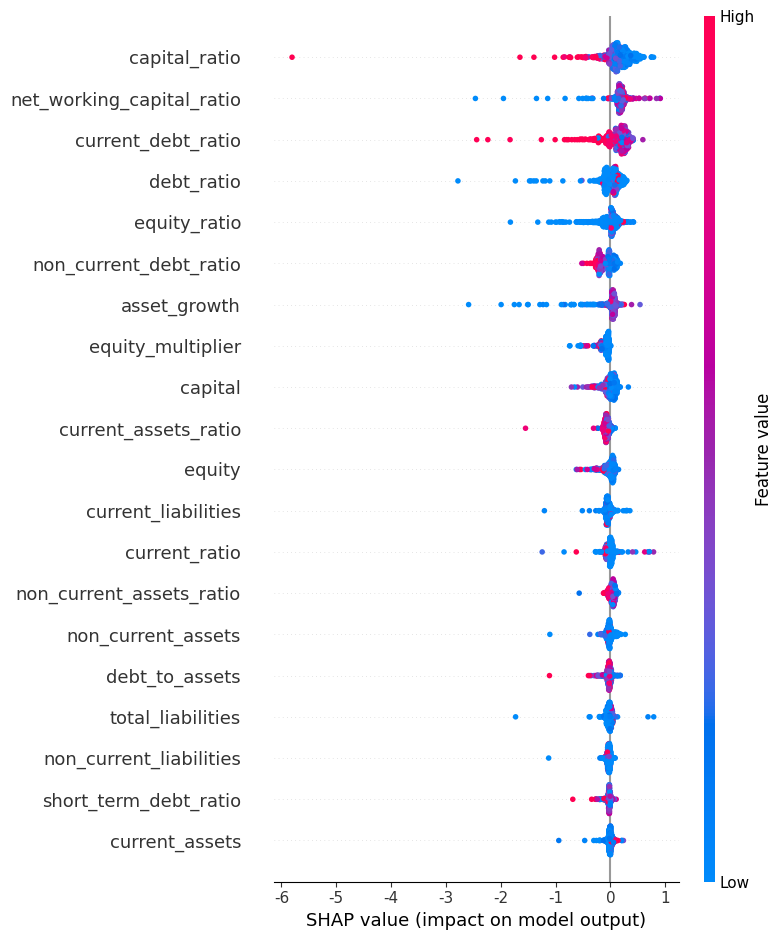

[Bar] 평균 |SHAP| 크기 기준 피처 중요도


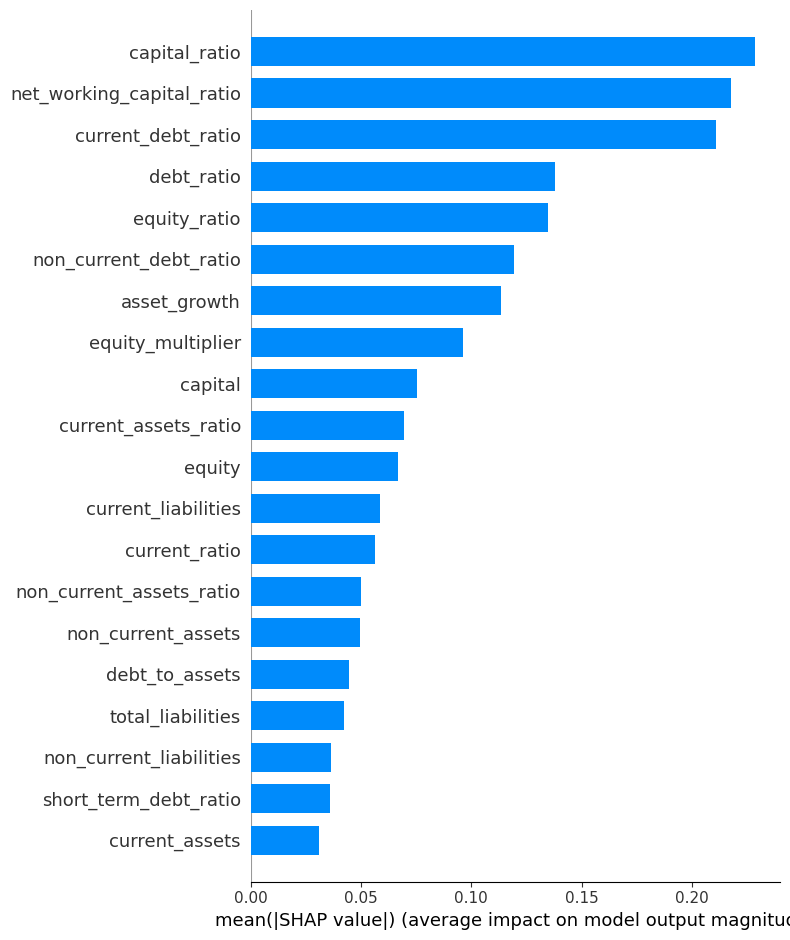


[평균 |SHAP| Top 20]
                  feature  mean_abs_shap
            capital_ratio       0.228537
net_working_capital_ratio       0.217675
       current_debt_ratio       0.210833
               debt_ratio       0.137827
             equity_ratio       0.134689
   non_current_debt_ratio       0.119176
             asset_growth       0.113455
        equity_multiplier       0.096450
                  capital       0.075552
     current_assets_ratio       0.069343
                   equity       0.066907
      current_liabilities       0.058504
            current_ratio       0.056239
 non_current_assets_ratio       0.049793
       non_current_assets       0.049577
           debt_to_assets       0.044757
        total_liabilities       0.042398
  non_current_liabilities       0.036337
    short_term_debt_ratio       0.035824
           current_assets       0.030929


In [110]:
# ── SHAP 분석 ─────────────────────────────────────────────────────────
sample_idx = X_valid.sample(min(500, len(X_valid)), random_state=42).index
X_shap = X_valid.loc[sample_idx]

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)
print(f'SHAP 완료: {X_shap.shape[0]}샘플 × {X_shap.shape[1]}피처')

# Beeswarm Plot
print('[Beeswarm] 피처별 SHAP 값 분포 (색상: 피처 크기)')
shap.summary_plot(shap_values, X_shap, show=True, max_display=20)

# Bar Plot
print('[Bar] 평균 |SHAP| 크기 기준 피처 중요도')
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=True, max_display=20)

# SHAP Top 20 테이블
mean_shap = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
print('\n[평균 |SHAP| Top 20]')
print(mean_shap.head(20).to_string(index=False))

[잘 예측] 기업: 260660.0 (2022년) (2분기) | 실제: 100점 | 예측: 100.0점 | 절대오차: 0.0


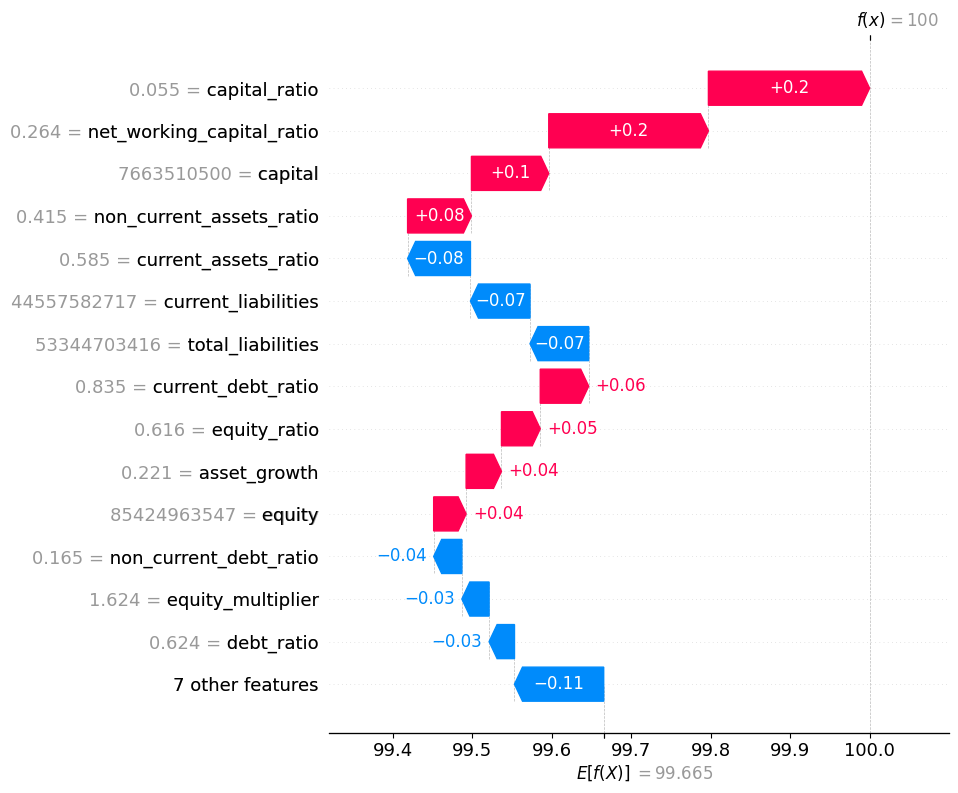

[못 예측] 기업: 5110.0 (2023년) (4분기) | 실제: 20점 | 예측: 92.4점 | 절대오차: 72.4


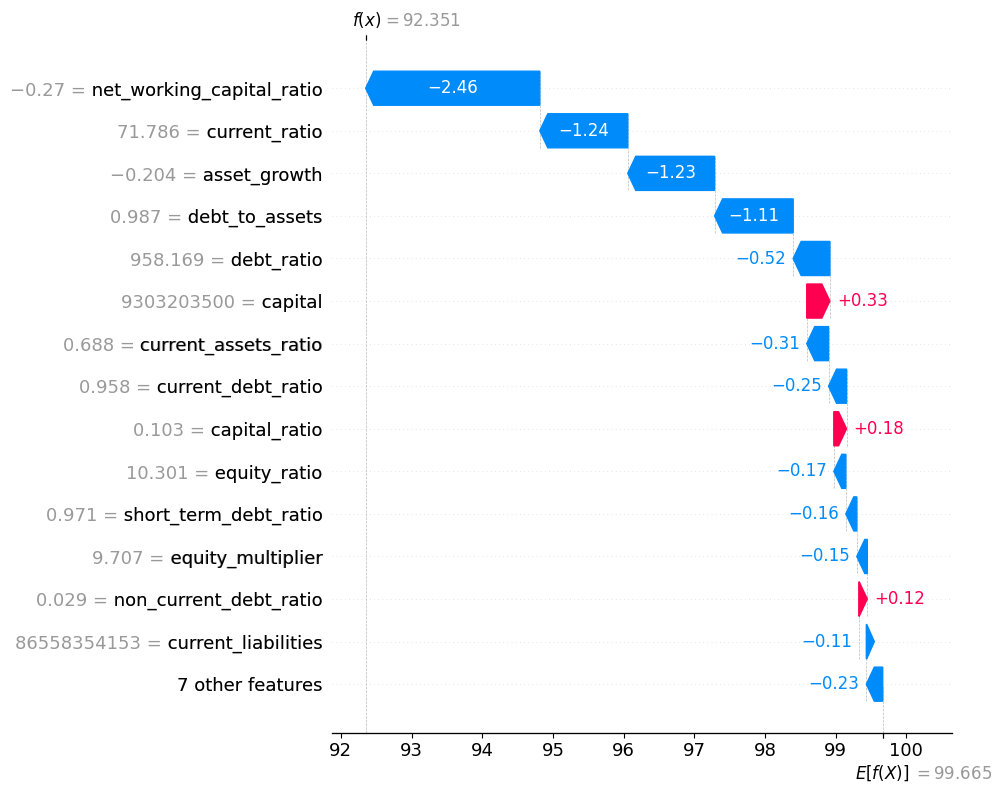

In [111]:
# ── Waterfall: 잘/못 예측한 기업 개별 해석 ─────────────────────────────────
pred_shap = best_model.predict(X_shap)
shap_meta = clean_df.loc[sample_idx, ['stock_code', 'year', 'quarter', 'target_score_t1']].copy()
shap_meta['pred'] = pred_shap
shap_meta['idx']  = range(len(shap_meta))
shap_meta['abs_err'] = (shap_meta['pred'] - shap_meta['target_score_t1']).abs()

# 잘 예측(오차 최소) 1개, 못 예측(오차 최대) 1개
best_row = shap_meta.sort_values('abs_err').head(1)
worst_row = shap_meta.sort_values('abs_err').tail(1)
show_rows = pd.concat([best_row, worst_row], axis=0)

for _, row in show_rows.iterrows():
    i = int(row['idx'])
    tag = '잘 예측' if row['abs_err'] == best_row['abs_err'].iloc[0] else '못 예측'
    print(f"[{tag}] 기업: {row['stock_code']} ({int(row['year'])}년) ({int(row['quarter'])}분기) | 실제: {row['target_score_t1']:.0f}점 | 예측: {row['pred']:.1f}점 | 절대오차: {row['abs_err']:.1f}")
    explanation = shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_shap.iloc[i].values,
        feature_names=X_shap.columns.tolist()
        )
    shap.plots.waterfall(explanation, max_display=15, show=True)